In [1]:
print ("AML Alert Triage Prototype")


AML Alert Triage Prototype


In [2]:
transactions = [
    {"customer":"ABC Imports","country":"UK","amount":950},
    {"customer":"Global Metals","country":"UAE","amount":45000},
    {"customer":"Northstar Trading","country":"Turkey","amount":62000}
]

transactions

[{'customer': 'ABC Imports', 'country': 'UK', 'amount': 950},
 {'customer': 'Global Metals', 'country': 'UAE', 'amount': 45000},
 {'customer': 'Northstar Trading', 'country': 'Turkey', 'amount': 62000}]

In [3]:
for t in transactions:

    score = 0

    if t["country"] in ["Turkey","UAE","Russia"]:
        score += 30

    if t["amount"] > 10000:
        score += 25

    print(t["customer"], score)

ABC Imports 0
Global Metals 55
Northstar Trading 55


In [4]:
for t in transactions:

    score = 0

    if t["country"] in ["Turkey","UAE","Russia"]:
        score += 30

    if t["amount"] > 10000:
        score += 25

    print(
        f"{t['customer']} generated a risk score of {score}. "
        f"Country={t['country']} Amount={t['amount']}"
    )

ABC Imports generated a risk score of 0. Country=UK Amount=950
Global Metals generated a risk score of 55. Country=UAE Amount=45000
Northstar Trading generated a risk score of 55. Country=Turkey Amount=62000


In [5]:
import pandas as pd

In [6]:
import pandas as pd

data = [
    {
        "Customer": "ABC Imports",
        "RiskRating": "Low",
        "Country": "UK",
        "Counterparty": "Supplier A",
        "Amount": 950,
        "UsualAverage": 1200,
        "NewCounterparty": "No",
        "AdverseMedia": "No"
    },
    {
        "Customer": "Global Metals Ltd",
        "RiskRating": "Medium",
        "Country": "UAE",
        "Counterparty": "Al Noor Trading",
        "Amount": 45000,
        "UsualAverage": 9000,
        "NewCounterparty": "Yes",
        "AdverseMedia": "No"
    },
    {
        "Customer": "Delta Commodities",
        "RiskRating": "High",
        "Country": "Russia",
        "Counterparty": "Volga Trade",
        "Amount": 38000,
        "UsualAverage": 8000,
        "NewCounterparty": "Yes",
        "AdverseMedia": "Yes"
    }
]

df = pd.DataFrame(data)
df

,Customer,RiskRating,Country,Counterparty,Amount,UsualAverage,NewCounterparty,AdverseMedia
0,ABC Imports,Low,UK,Supplier A,950,1200,No,No
1,Global Metals Ltd,Medium,UAE,Al Noor Trading,45000,9000,Yes,No
2,Delta Commodities,High,Russia,Volga Trade,38000,8000,Yes,Yes


In [7]:
high_risk_countries = [
    "Russia",
    "Iran",
    "North Korea",
    "Turkey",
    "UAE"
]

def calculate_risk(row):

    score = 0
    reasons = []

    if row["Country"] in high_risk_countries:
        score += 30
        reasons.append("High Risk Country")

    if row["Amount"] > row["UsualAverage"] * 3:
        score += 25
        reasons.append("Unusual Transaction Value")

    if row["NewCounterparty"] == "Yes":
        score += 20
        reasons.append("New Counterparty")

    if row["AdverseMedia"] == "Yes":
        score += 25
        reasons.append("Adverse Media")

    if row["RiskRating"] == "High":
        score += 15
        reasons.append("High Customer Risk")

    return score, reasons

In [8]:
df[["RiskScore","RiskReasons"]] = df.apply(
    lambda row: pd.Series(calculate_risk(row)),
    axis=1
)

df

,Customer,RiskRating,Country,Counterparty,Amount,UsualAverage,NewCounterparty,AdverseMedia,RiskScore,RiskReasons
0,ABC Imports,Low,UK,Supplier A,950,1200,No,No,0,[]
1,Global Metals Ltd,Medium,UAE,Al Noor Trading,45000,9000,Yes,No,75,"[High Risk Country, Unusual Transaction Value,..."
2,Delta Commodities,High,Russia,Volga Trade,38000,8000,Yes,Yes,115,"[High Risk Country, Unusual Transaction Value,..."


In [9]:
def investigator_summary(row):

    return f"""
Customer: {row['Customer']}

Risk Score: {row['RiskScore']}

Risk Indicators:
{', '.join(row['RiskReasons'])}

Investigator Recommendation:
Review transaction activity and perform Enhanced Due Diligence due to identified risk indicators.
"""

In [10]:
df["InvestigatorSummary"] = df.apply(
    investigator_summary,
    axis=1
)

df[["Customer","RiskScore","InvestigatorSummary"]]

,Customer,RiskScore,InvestigatorSummary
0,ABC Imports,0,\nCustomer: ABC Imports\n\nRisk Score: 0\n\nRi...
1,Global Metals Ltd,75,\nCustomer: Global Metals Ltd\n\nRisk Score: 7...
2,Delta Commodities,115,\nCustomer: Delta Commodities\n\nRisk Score: 1...


In [11]:
for summary in df["InvestigatorSummary"]:
    print(summary)
    print("-" * 60)


Customer: ABC Imports

Risk Score: 0

Risk Indicators:


Investigator Recommendation:
Review transaction activity and perform Enhanced Due Diligence due to identified risk indicators.

------------------------------------------------------------

Customer: Global Metals Ltd

Risk Score: 75

Risk Indicators:
High Risk Country, Unusual Transaction Value, New Counterparty

Investigator Recommendation:
Review transaction activity and perform Enhanced Due Diligence due to identified risk indicators.

------------------------------------------------------------

Customer: Delta Commodities

Risk Score: 115

Risk Indicators:
High Risk Country, Unusual Transaction Value, New Counterparty, Adverse Media, High Customer Risk

Investigator Recommendation:
Review transaction activity and perform Enhanced Due Diligence due to identified risk indicators.

------------------------------------------------------------


In [12]:
df[["Customer", "RiskScore", "RiskReasons"]]

,Customer,RiskScore,RiskReasons
0,ABC Imports,0,[]
1,Global Metals Ltd,75,"[High Risk Country, Unusual Transaction Value,..."
2,Delta Commodities,115,"[High Risk Country, Unusual Transaction Value,..."


In [13]:
def risk_level(score):
    if score >= 90:
        return "High"
    elif score >= 50:
        return "Medium"
    else:
        return "Low"

df["RiskLevel"] = df["RiskScore"].apply(risk_level)

df[["Customer", "RiskScore", "RiskLevel", "RiskReasons"]]

,Customer,RiskScore,RiskLevel,RiskReasons
0,ABC Imports,0,Low,[]
1,Global Metals Ltd,75,Medium,"[High Risk Country, Unusual Transaction Value,..."
2,Delta Commodities,115,High,"[High Risk Country, Unusual Transaction Value,..."


In [14]:
df.sort_values("RiskScore", ascending=False)

,Customer,RiskRating,Country,Counterparty,Amount,UsualAverage,NewCounterparty,AdverseMedia,RiskScore,RiskReasons,InvestigatorSummary,RiskLevel
2,Delta Commodities,High,Russia,Volga Trade,38000,8000,Yes,Yes,115,"[High Risk Country, Unusual Transaction Value,...",\nCustomer: Delta Commodities\n\nRisk Score: 1...,High
1,Global Metals Ltd,Medium,UAE,Al Noor Trading,45000,9000,Yes,No,75,"[High Risk Country, Unusual Transaction Value,...",\nCustomer: Global Metals Ltd\n\nRisk Score: 7...,Medium
0,ABC Imports,Low,UK,Supplier A,950,1200,No,No,0,[],\nCustomer: ABC Imports\n\nRisk Score: 0\n\nRi...,Low


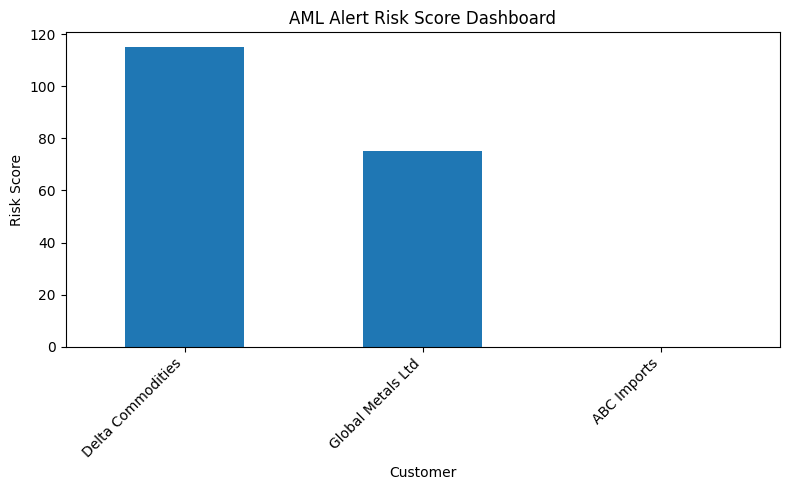

In [15]:
import matplotlib.pyplot as plt

# Sort highest-risk customers first
risk_dashboard = df.sort_values("RiskScore", ascending=False)

# Create bar chart
risk_dashboard.plot(
    x="Customer",
    y="RiskScore",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("AML Alert Risk Score Dashboard")
plt.xlabel("Customer")
plt.ylabel("Risk Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
def risk_status(score):

    if score >= 100:
        return "🔴 Critical"

    elif score >= 50:
        return "🟠 Medium"

    else:
        return "🟢 Low"

df["AlertStatus"] = df["RiskScore"].apply(risk_status)

df[["Customer","RiskScore","AlertStatus"]]

,Customer,RiskScore,AlertStatus
0,ABC Imports,0,🟢 Low
1,Global Metals Ltd,75,🟠 Medium
2,Delta Commodities,115,🔴 Critical


In [17]:
risk_dashboard[["Customer", "RiskScore", "RiskLevel", "RiskReasons"]]

,Customer,RiskScore,RiskLevel,RiskReasons
2,Delta Commodities,115,High,"[High Risk Country, Unusual Transaction Value,..."
1,Global Metals Ltd,75,Medium,"[High Risk Country, Unusual Transaction Value,..."
0,ABC Imports,0,Low,[]


In [18]:
risk_dashboard = df.sort_values(
    "RiskScore",
    ascending=False
)

In [19]:
for index, row in risk_dashboard.iterrows():

    print("=" * 60)

    print(row["Customer"])

    print("Risk Score:", row["RiskScore"])

    print("Status:", row["AlertStatus"])

    print("Indicators:")

    for reason in row["RiskReasons"]:
        print("-", reason)

    print()

Delta Commodities
Risk Score: 115
Status: 🔴 Critical
Indicators:
- High Risk Country
- Unusual Transaction Value
- New Counterparty
- Adverse Media
- High Customer Risk

Global Metals Ltd
Risk Score: 75
Status: 🟠 Medium
Indicators:
- High Risk Country
- Unusual Transaction Value
- New Counterparty

ABC Imports
Risk Score: 0
Status: 🟢 Low
Indicators:



In [20]:
df.to_csv("sample_transactions.csv", index=False)

In [21]:
with open("output_sample.txt", "w") as file:
    for index, row in risk_dashboard.iterrows():
        file.write("=" * 60 + "\n")
        file.write(f"Customer: {row['Customer']}\n")
        file.write(f"Risk Score: {row['RiskScore']}\n")
        file.write(f"Status: {row['AlertStatus']}\n")
        file.write("Indicators:\n")

        for reason in row["RiskReasons"]:
            file.write(f"- {reason}\n")

        file.write("\n")

In [28]:
readme_text = """# AML Alert Triage Prototype

# aml-alert-triage-prototype

# AML Alert Triage Prototype
This is a small Python prototype demonstrating how transaction monitoring alerts can be risk-scored and summarised for investigator review.

## Context
This project is part of my development in Python, AI-enabled financial crime transformation and transaction monitoring analytics.

It is not intended to replace enterprise transaction monitoring platforms. It demonstrates how simple analytics and rule-based scoring can support alert prioritisation and investigator workflow design.

## Purpose
The objective is to show how basic Python logic can support Financial Crime Operations by:

- scoring alerts against AML risk indicators
- identifying high-risk jurisdictions
- detecting transaction spikes
- flagging new counterparties
- incorporating adverse media indicators
- generating investigator-style summaries
- prioritising higher-risk cases
- visualising alert risk scores

## Files
- AML_Alert_Triage_Prototype.ipynb - Jupyter notebook containing the prototype logic
- sample_transactions.csv - sample AML alert dataset
- Dashboard.png - example risk dashboard output
- README.md - project documentation

## Outputs
The prototype produces:

- AML risk score
- Alert status
- Risk reasons
- Prioritised alert queue
- Investigator summary
- Risk dashboard chart

## Example Output
Customer: Global Metals Ltd

Risk Score: 75
Alert Status: Medium

Risk Indicators:
- High Risk Country
- Unusual Transaction Value
- New Counterparty

Recommendation:
Escalate for enhanced investigation.

Investigator Summary:
Customer Global Metals Ltd generated an AML alert with a risk score of 75. Key risk indicators include high-risk jurisdiction exposure, transaction value significantly above customer baseline and a newly established counterparty relationship.

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

## Future Enhancements

### AI Investigator Copilot
Integrate a Large Language Model (LLM) to generate enhanced investigator narratives, case summaries and recommended next actions.

### Entity Resolution & Network Analytics
Incorporate Quantexa-style network analysis to identify hidden relationships between customers, counterparties and transactions.

### Dynamic Segmentation Risk Weighting
Replace static risk scores with configurable risk-weight models driven by customer, geography and behavioural attributes.

### Alert Prioritisation Engine
Introduce queue management logic to rank alerts based on risk severity, investigator capacity and SLA requirements.

### Adverse Media Intelligence
Integrate external adverse media and sanctions screening feeds to automatically enrich alerts.

### SAR Narrative Drafting
Generate Suspicious Activity Report (SAR) draft narratives to accelerate investigator workflow.

### Machine Learning Risk Models
Move from rule-based scoring to supervised learning models trained on historical investigation outcomes.

### Case Management Integration
Connect the prototype to transaction monitoring and case management platforms for end-to-end workflow automation.

### Executive Dashboard
Create a web-based dashboard showing:

- Alert volumes
- High-risk customers
- Alert ageing
- Investigator productivity
- Risk trends

## Disclaimer
This project is a learning prototype intended for demonstration purposes only.

It does not represent a production-grade AML monitoring solution and should not be used for regulatory decision-making. The scoring methodology is intentionally simplified to demonstrate Python-based risk assessment concepts.

"""
with open("README.md", "w") as file:
    file.write(readme_text)

In [23]:
import os
print(os.getcwd())

/Users/danhartwig
